In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

In [2]:
path = "outputs/"

# Metropolis Algorithm: sampling Hydrogenic wave functions

In quantum mechanics, the state of a spinless particle is fully described by its wave function $\Psi(\vec{r},t)$. The square modulus of the wave function, $|\Psi(\vec{r},t)|^2$, represents the probability density function of finding the particle at position $\vec{r}$ at time $t$.

The goal of this exercise is to use the Metropolis algorithm to sample the spatial probability distribution of an electron in a Hydrogen atom and to compute the expectation value of its radius, $\langle r \rangle$, for two specific eigenstates: the ground state ($1s$) and the first excited state ($2p$).


## The Metropolis-Hastings Algorithm $M(RT)^2$
To sample these complex probability distributions, we rely on the Metropolis algorithm. The method is based on the theory of Markov stochastic processes. In statistical mechanics, a system naturally evolves towards an equilibrium state governed by a known stochastic transition matrix $K(x|y)$. The $M(RT)^2$ algorithm conceptually reverses this problem: given a target probability distribution $p(x)$ (in our case, $|\Psi|^2$), the task is to construct a regular and ergodic stochastic kinetics $K(x|y)$ that will naturally equilibrate the system exactly to $p(x)$.

To guarantee that $p(x)$ is the invariant probability distribution of the generated Markov chain, the algorithm enforces the detailed balance property:$$K(x|y)p(y) = K(y|x)p(x)$$ which ensures that the transition rate from state $y$ to $x$ is perfectly balanced by the reverse transition.

To fulfill this condition, the algorithm decomposes the transition probability $K(x|y)$ into the product of a trial transition probability $T(x|y)$ and an acceptance probability $A(x|y)$. The $M(RT)^2$ algorithm suggests the following optimal choice for the acceptance:

$$A(x|y) = \min \left[ 1, \frac{T(y|x)p(x)}{T(x|y)p(y)} \right]$$

A fundamental computational advantage of this formulation is that it only requires the ratio of the probabilities. Consequently, any normalization constant of the target distribution $p(x)$ perfectly cancels out.

## Application to Hydrogen atom
Exploiting the irrelevance of normalization constants, the computational model was simplified to evaluate the unnormalized PDFs directly in Cartesian coordinates $(x, y, z)$, setting the Bohr radius $a_0 = 1$ (atomic units). The sampled distributions for the two eigenstates are thus:

- **Ground State ($1s$ or $n=1, l=0, m=0$):**$$|\Psi_{1,0,0}(x,y,z)|^2 \propto e^{-2r}$$where $r = \sqrt{x^2 + y^2 + z^2}$. The theoretical expectation value for the radius is $\langle r \rangle _{1s} = 1.5 a_0$.

- **Excited State ($2p$ or $n=2, l=1, m=0$):**$$|\Psi_{2,1,0}(x,y,z)|^2 \propto r^2 e^{-r} \cos^2(\theta) = z^2 e^{-r}$$where we used the Cartesian substitution $z = r \cos(\theta)$. The theoretical expectation value is $\langle r \rangle _{2p} = 5.0 a_0$.

## MetropolisAlgorithm Class

To perform the sampling I developed the MetropolisAlgorithm\<Distribution\>. This architecture allows the algorithm to accept any arbitrary probability distribution function (passed as a functor, e.g., Psi100 or Psi210) without rewriting the core Monte Carlo logic.

The simulation strictly follows the $M(RT)^2$ steps:

- **Symmetric Tentative Moves:** The tentative_move method proposes a new spatial position $x'$ starting from $x_n$. The algorithm supports both uniform box displacements and Gaussian steps. Since both distributions are symmetric ($T(x'|x_n) = T(x_n|x')$), the acceptance probability greatly simplifies to $A(x'|x_n) = \min[1, p(x')/p(x_n)]$.
- **Acceptance/Rejection:** A uniform random number $\mathcal{R} \in [0,1]$ is extracted. If $\mathcal{R} \le A(x'|x_n)$, the move is accepted ($x_{n+1} = x'$); otherwise, the move is rejected and the particle remains in its current position ($x_{n+1} = x_n$).

To ensure statistical rigor and efficiency, the class features several automated tools:
- **Empirical Tuning (`tune_step`):** The choice of the step size in $T(x'|x_n)$ deeply influences the algorithm's efficiency. If the step is too large, the proposed moves fall in low-probability regions and are systematically rejected. If the step is too small, moves are easily accepted but the spatial correlation between consecutive states becomes extremely high. To solve this, the `tune_step` method performs a preliminary run, dynamically adjusting the step size until an optimal acceptance rate of $\approx 50\%$ is reached, complying with the standard empirical rule of Monte Carlo methods.
- **Equilibration (`equilibrate`):** The sampling of the Metropolis algorithm is correct only asymptotically. Before collecting any physical measurements, the system must undergo a "burn-in" phase. The equilibrate method runs the Markov chain for a specific number of steps without recording data, allowing the system to lose memory of the arbitrary starting coordinates and securely reach the stationary distribution.
- **Data Blocking:** Because successive variables produced by the Markov chain are intrinsically correlated, the mean radius estimations were evaluated using the Data Blocking technique. The total number of steps $N$ was divided into $N_{blocks}$, with each block being significantly longer than the system's autocorrelation time, ensuring independent measurements and a reliable estimation of the statistical uncertainties.

### Memory and autocorrelation

In complex systems, memory is the ability of past events to act as an influence on future dynamics. Because the Metropolis algorithm generates the next spatial position based solely on the current one, the successive random variables produced are strictly correlated.To quantify this statistical dependence, we evaluate the autocorrelation function of the stationary random process $r(t)$. The autocorrelation evaluates the statistical covariance of the process with a time-delayed copy of itself. For any time lag $\tau > 0$, it is defined as:

$$Ac_{[r]}(\tau) = \frac{\langle r(t)r(t+\tau) \rangle - \langle r(t) \rangle \langle r(t+\tau) \rangle}{\sigma_r^2}$$ 
where the denominator reduces to the variance of the process at time $t$. Thanks to the assumed stationarity of the process, the autocorrelation is independent of $t$.

For the Metropolis random walk, the tail of the autocorrelation typically exhibits an exponential decay modeled as $Ac_{[r]}(\tau) = \exp(-\tau/\tau_c)$. In this functional form, the parameter $\tau_c$ provides an estimate for how long the process remembers about itself. If $Ac_{[r]}(\tau) = 0$ for $\tau > \tau_c$, it implies that the process becomes independent of its past history only after a lapse of time $\tau_c$. Estimating $\tau_c$ is strictly required to determine the optimal block size $L$ for the Data Blocking technique, ensuring that each block contains statistically independent measurements.

To rigorously measure the correlation time without mathematical artifacts, the sequence of data must be strictly stationary. If the autocorrelation were computed on a sequence that includes the initial "fall" toward the equilibrium state (the transient phase), the formula would misinterpret the persistent trend as a long-term memory, leading to an artificially inflated $\tau_c$.To solve this, an automated Python orchestration script (`pipeline.py` in `src/autocorrelation`) was developed to handle the entire preliminary analysis:

- **Raw Data Generation:** The script executes autocorr_generator.exe, which simulates the Metropolis algorithm for 500,000 steps without any prior equilibration. The raw instantaneous radii are saved to `.dat` files in `outputs/autocorr`.
- **Burn-in Detection (Moving Average):** To find the exact step where the transient phase ends, the Python script applies a simple moving average filter (with a window of 50 steps) to the raw data. This smooths out the local stochastic noise. The "burn-in" time is defined as the point where this moving average stably enters a tight tolerance band around the theoretical expected radius. The worst-case burn-in time among all combinations (1s, 2p, Uniform, Gaussian) is selected as the global equilibration standard.
- **Stationary Autocorrelation:** The raw arrays are sliced, discarding all data prior to the worst-case burn-in index. The empirical autocorrelation is then computed exclusively on the thermalized data.
- **Parameter Export:** The script fits the decaying autocorrelation function $Ac(\tau)$ to the exponential model to extract $\tau_c$. Finally, it scales the worst-case parameters to generate completely safe settings ($10 \times \text{burn-in}$ for equilibration, $100 \times \tau_c$ for block length) and exports them to a `src/autocorrelation/config.txt` file, which is automatically read by the main C++ simulation.


The execution of the pipeline automatically produces visual diagnostics of both the equilibration phase and the autocorrelation decay. Below are the generated plots loaded directly from the `outputs/autocorr` directory.

### Equilibration Phase (Burn-in)
The following graph highlights the initial transient phase. The vertical line marks the algorithm's automated detection of the burn-in threshold, safely excluding the initial collapse toward the equilibrium value.

![Grafico Autocorrelazione](outputs/autocorr/equilibration_analysis.png)

### Autocorrelation Decay

Calculated strictly on the thermalized data, the empirical autocorrelation beautifully matches the theoretical exponential decay $Ac(\tau) = \exp(-\tau/\tau_c)$. The extracted correlation times range between 10.8 and 12.1 steps, confirming that a block length of $L \approx 1200$ guarantees rigorous statistical independence for the Data Blocking technique.

![Grafico Autocorrelazione](outputs/autocorr/autocorrelation_analysis.png)

## Main Simulation and Data Collection

With the physical parameters rigorously estimated by the exploratory Python pipeline, the final data collection is executed by the main C++ program (`exercise05-1.cpp`). This program evaluates the expectation values of the radius $\langle r \rangle$ for both the $1s$ and $2p$ states using both Uniform and Gaussian transition probabilities.

To completely decouple the analytical setup from the source code, the C++ program dynamically reads its execution parameters from the `autocorrelation/config.txt` file generated by the Python pipeline. Using the standard ifstream library, the program loads the "worst-case scenario" parameters ensuring statistical safety across all configurations:
- **Equilibration Steps (n_equilibration_steps):** Set to 5790 steps (10 times the longest burn-in phase detected).
- **Block Length (L):** Set to 1212 steps (100 times the longest autocorrelation time $\tau_c$).
- **Number of Blocks (M):** Fixed to 100 to guarantee a robust statistical evaluation of the uncertainties.
- **Total Steps (N):** Calculated as $L \times M = 121200$ steps.

This architecture ensures that the simulation relies exclusively on physically measured time scales rather than hard-coded heuristics.

For each transition probability distribution (Uniform and Gaussian), the simulation executes the following steps:

- **Step Tuning:** The starting coordinates are initialized to $\vec{r}_{start} = (1.0, 1.0, 1.0)$. Before any data is collected, the tune_step method performs a preliminary random walk to dynamically calibrate the trial step size (_step). The algorithm scales the step until the acceptance rate falls within the optimal $50\% \pm 5\%$ window.
- **Position Reset and Thermalization:** Because the tuning phase displaces the particles, the coordinates are strictly reverted to their initial values using the reset_position() method. Subsequently, the equilibrate() method runs the Markov chain "silently" for 5790 steps. This enforces the complete loss of initial memory, ensuring the system reaches the invariant probability distribution.
- **Data Generation and On-the-Fly Blocking:** The core Monte Carlo loop runs for the calculated $N = 121200$ steps. At each step: 
    - The Metropolis move is attempted and either accepted or rejected.
    - The 3D Cartesian coordinates $(x, y, z)$ are saved to an output file for subsequent spatial visualization.
    - The instantaneous radius $r = \sqrt{x^2 + y^2 + z^2}$ is evaluated and fed into the DataBlocker object.
    - Statistical Evaluation: Instead of storing large arrays in memory, the DataBlocker processes the incoming measurements on the fly. Once exactly $L$ measurements have been accumulated, a new block is considered complete. The object calculates the block average and the progressive statistical uncertainty (standard deviation of the mean), immediately writing the updated cumulative average and error to the output files.

## Uniform tentative distribution

### Plotting positions: orbital shape

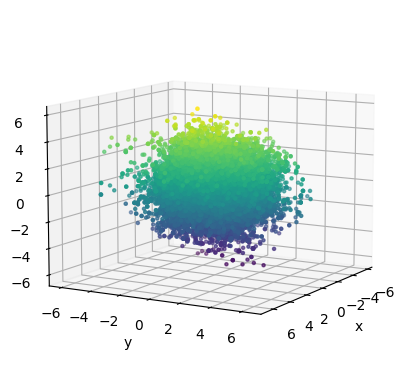

In [3]:
# 1S ORBITAL

X, Y, Z = np.loadtxt(path + '05_1_pos100_U.dat', unpack=True)

fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.scatter(X, Y, Z, c=Z, marker='.')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.view_init(10, 30)

plt.show()

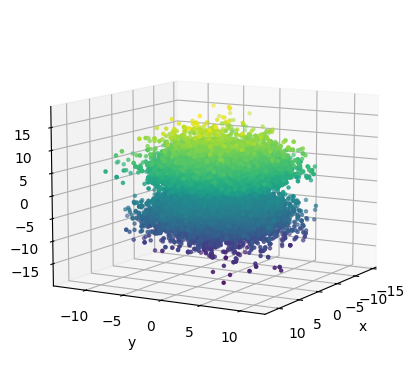

In [4]:
# 2P ORBITAL

X, Y, Z = np.loadtxt(path + '05_1_pos210_U.dat', unpack=True)

fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.scatter(X, Y, Z, c=Z, marker='.')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.view_init(10, 30)

plt.show()

### Plotting radius

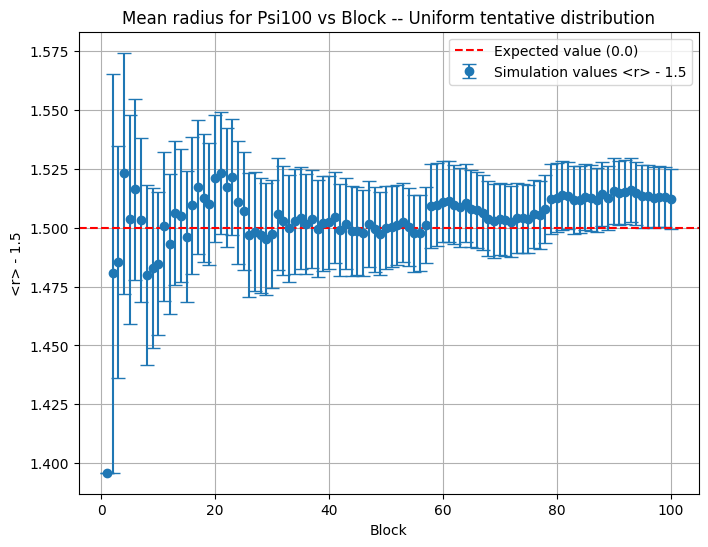

In [5]:
# 1S ORBITAL

block, r, err_r = np.loadtxt(path + '05_1_r100_U.dat', unpack=True)

theo_r = 1.5

fig = plt.figure(figsize=(8, 6))
plt.errorbar(block, r, yerr=err_r, fmt='o', label='Simulation values <r> - 1.5', capsize=5)
plt.axhline(theo_r, color='red', linestyle='--', label='Expected value (0.0)')
plt.xlabel('Block')
plt.ylabel('<r> - 1.5')
plt.title('Mean radius for Psi100 vs Block -- Uniform tentative distribution')
plt.legend()
plt.grid()
plt.show()

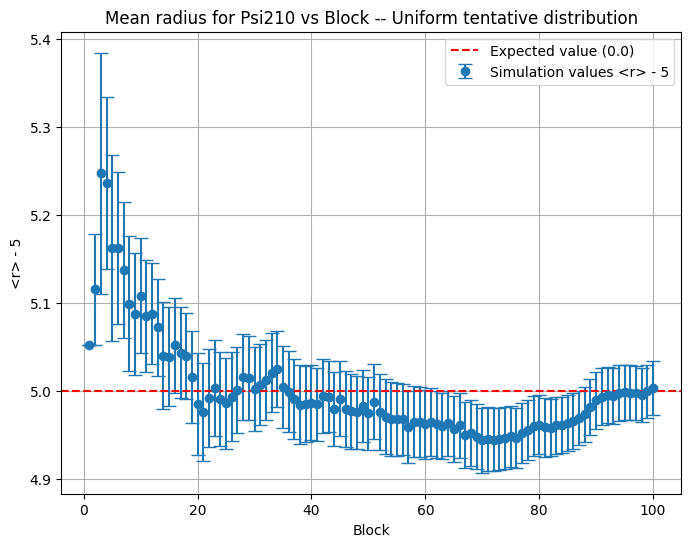

In [6]:
# 2P ORBITAL

block, r, err_r = np.loadtxt(path + '05_1_r210_U.dat', unpack=True)

theo_r = 5

fig = plt.figure(figsize=(8, 6))
plt.errorbar(block, r, yerr=err_r, fmt='o', label='Simulation values <r> - 5', capsize=5)
plt.axhline(theo_r, color='red', linestyle='--', label='Expected value (0.0)')
plt.xlabel('Block')
plt.ylabel('<r> - 5')
plt.title('Mean radius for Psi210 vs Block -- Uniform tentative distribution')
plt.legend()
plt.grid()
plt.show()

## Gaussian tentative distribution

### Plotting

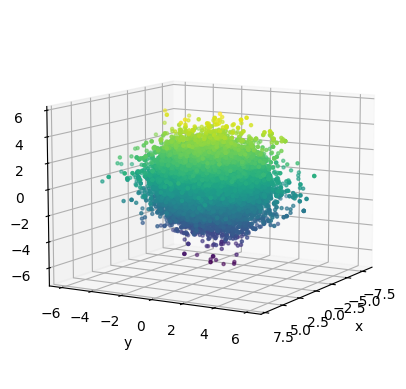

In [7]:
X, Y, Z = np.loadtxt(path + '05_1_pos100_G.dat', unpack=True)

fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.scatter(X, Y, Z, c=Z, marker='.')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.view_init(10, 30)

plt.show()

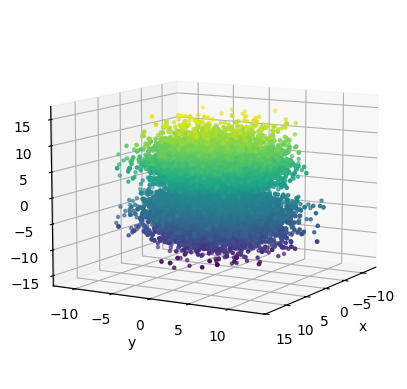

In [8]:
X, Y, Z = np.loadtxt(path + '05_1_pos210_G.dat', unpack=True)

fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.scatter(X, Y, Z, c=Z, marker='.')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.view_init(10, 30)

plt.show()

### Plotting radius

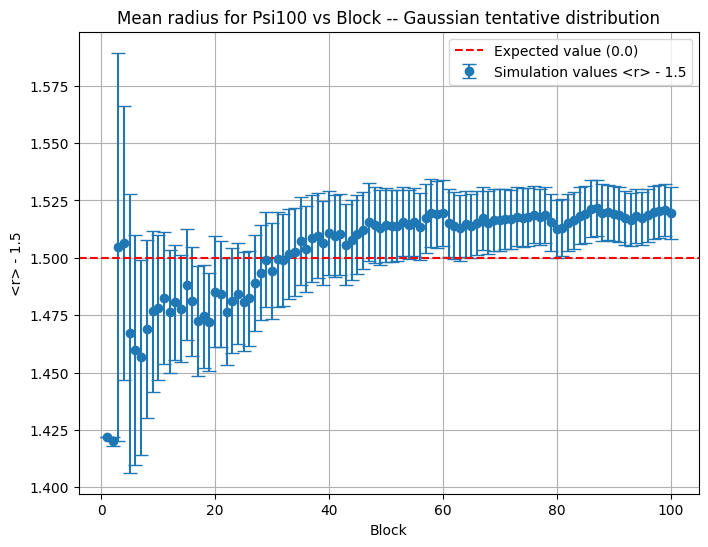

In [9]:
block, r, err_r = np.loadtxt(path + '05_1_r100_G.dat', unpack=True)

theo_r = 1.5

fig = plt.figure(figsize=(8, 6))
plt.errorbar(block, r, yerr=err_r, fmt='o', label='Simulation values <r> - 1.5', capsize=5)
plt.axhline(theo_r, color='red', linestyle='--', label='Expected value (0.0)')
plt.xlabel('Block')
plt.ylabel('<r> - 1.5')
plt.title('Mean radius for Psi100 vs Block -- Gaussian tentative distribution')
plt.legend()
plt.grid()
plt.show()

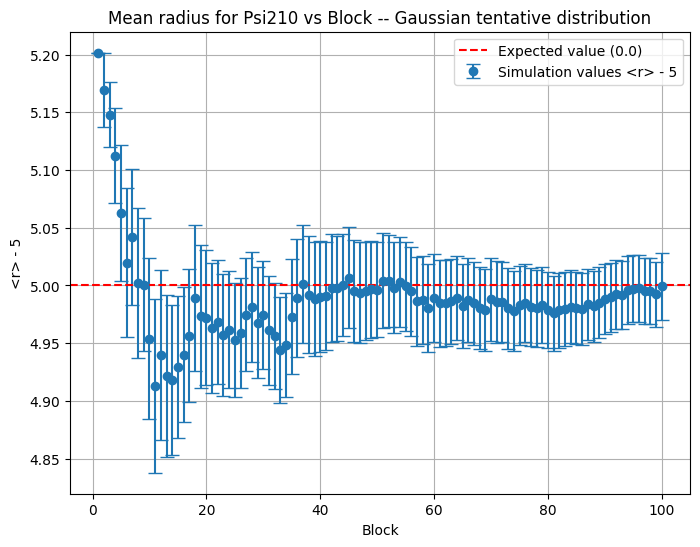

In [10]:
block, r, err_r = np.loadtxt(path + '05_1_r210_G.dat', unpack=True)

theo_r = 5

fig = plt.figure(figsize=(8, 6))
plt.errorbar(block, r, yerr=err_r, fmt='o', label='Simulation values <r> - 5', capsize=5)
plt.axhline(theo_r, color='red', linestyle='--', label='Expected value (0.0)')
plt.xlabel('Block')
plt.ylabel('<r> - 5')
plt.title('Mean radius for Psi210 vs Block -- Gaussian tentative distribution')
plt.legend()
plt.grid()
plt.show()